# Hamiltonian Monte Carlo with BlackJAX

The preceding notebook used local random-walk proposals. We now keep the target distribution fixed and change only the transition mechanism. HMC uses the gradient of the log density to construct longer proposals, then applies a Metropolis correction for numerical integration error {cite:p}`neal2011hmc`. This notebook connects the construction in the preceding theory section to BlackJAX {cite:p}`cabezas2024blackjax`.


In [1]:
import blackjax
import jax
import jax.numpy as jnp
import jax.random as jrandom
from blackjax.mcmc import integrators, metrics
from jax import lax, vmap
from jax.scipy.stats import multivariate_normal

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib_inline
import numpy as np
import os
from html import escape
from IPython.display import display
from scipy.stats import rankdata

jax.config.update("jax_enable_x64", True)
os.environ.setdefault("SOURCE_DATE_EPOCH", "1789776000")
matplotlib_inline.backend_inline.set_matplotlib_formats("svg", "png", "pdf")

FIGURE_SIZES = {
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_tall": (3.55, 3.05),
}

CHAIN_STYLES = [
    ("0.10", "-"),
    ("0.35", "--"),
    ("0.55", "-."),
    ("0.70", ":"),
]

mpl.rcParams.update(
    {
        "figure.dpi": 300,
        "savefig.dpi": 300,
        "font.family": "sans-serif",
        "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "axes.linewidth": 0.8,
        "axes.grid": False,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.frameon": False,
        "lines.linewidth": 1.1,
        "svg.hashsalt": "me697-t23-hmc",
    }
)


def finish_axes(axes, *, boxed=False):
    for ax in np.atleast_1d(axes).ravel():
        ax.grid(False)
        ax.spines["top"].set_visible(boxed)
        ax.spines["right"].set_visible(boxed)
    return axes


def display_book_table(
    headers,
    rows,
    latex_source,
    *,
    html_headers=None,
    html_rows=None,
):
    # Display one compact table in HTML, LaTeX, and plain-text formats.
    if html_headers is None:
        html_headers = [escape(str(value)) for value in headers]
    if html_rows is None:
        html_rows = [[escape(str(value)) for value in row] for row in rows]
    head = "".join(f"<th>{value}</th>" for value in html_headers)
    body = "".join(
        "<tr>" + "".join(f"<td>{value}</td>" for value in row) + "</tr>"
        for row in html_rows
    )
    html_source = (
        '<table class="table table-sm">'
        f"<thead><tr>{head}</tr></thead><tbody>{body}</tbody></table>"
    )
    widths = [
        max(len(str(value)) for value in [header] + [row[i] for row in rows])
        for i, header in enumerate(headers)
    ]
    plain_rows = [headers] + rows
    plain_source = "\n".join(
        "  ".join(str(value).ljust(widths[i]) for i, value in enumerate(row))
        for row in plain_rows
    )
    display(
        {
            "text/plain": plain_source,
            "text/html": html_source,
            "text/latex": latex_source,
        },
        raw=True,
    )


## Banana-shaped target

We use the same target as in the random-walk notebook. Let

$$
U=
\begin{bmatrix}U_1\\U_2\end{bmatrix}
\sim
\mathcal{N}\!\left(0,\Sigma_\rho\right),
\qquad
\Sigma_\rho=
\begin{bmatrix}
1 & \rho\\
\rho & 1
\end{bmatrix},
$$

and define

$$
X_1=aU_1,
\qquad
X_2=\frac{U_2}{a}+b\left(U_1^2+a^2\right).
$$

We take $a=1.15$, $b=0.5$, and $\rho=0.9$, as in the banana-shaped example of {cite:t}`wang2019hmcsubset`. The inverse transformation is

$$
u_1(x)=\frac{x_1}{a},
\qquad
u_2(x)=a\left[x_2-b\left(\left(\frac{x_1}{a}\right)^2+a^2\right)\right].
$$

Its Jacobian determinant is one, so the normalized target density is $\pi(x)=\phi_{\Sigma_\rho}(u(x))$, where $x=(x_1,x_2)^{\mathsf T}\in\mathbb{R}^2$ and $\phi_{\Sigma_\rho}$ is the centered Gaussian density with covariance $\Sigma_\rho$.


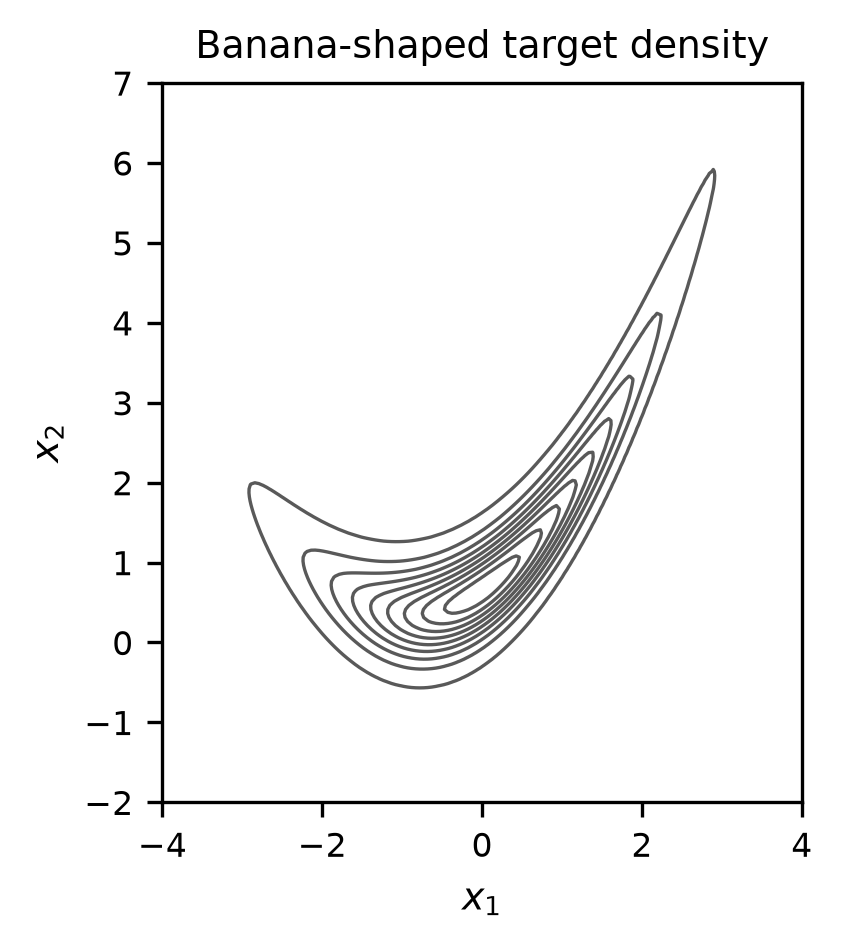

In [2]:
a = 1.15
b = 0.5
rho = 0.9
correlation = jnp.array([[1.0, rho], [rho, 1.0]])


def banana_logdensity(x):
    # Log density induced by the unit-Jacobian banana transformation.
    x1, x2 = x
    u1 = x1 / a
    u2 = a * (x2 - b * (u1**2 + a**2))
    u = jnp.array([u1, u2])
    return multivariate_normal.logpdf(u, jnp.zeros(2), correlation)


grid_x = jnp.linspace(-4.0, 4.0, 160)
grid_y = jnp.linspace(-2.0, 7.0, 180)
X_grid, Y_grid = jnp.meshgrid(grid_x, grid_y)
grid_points = jnp.stack([X_grid.ravel(), Y_grid.ravel()], axis=1)
target_density = jnp.exp(vmap(banana_logdensity)(grid_points)).reshape(X_grid.shape)


def draw_target_contours(ax):
    maximum = float(jnp.max(target_density))
    levels = np.linspace(0.04 * maximum, 0.92 * maximum, 9)
    ax.contour(
        np.asarray(X_grid),
        np.asarray(Y_grid),
        np.asarray(target_density),
        levels=levels,
        colors="0.35",
        linewidths=0.8,
    )
    ax.set_xlim(-4.0, 4.0)
    ax.set_ylim(-2.0, 7.0)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    finish_axes(ax, boxed=True)
    return ax


fig, ax = plt.subplots(figsize=FIGURE_SIZES["half_tall"], constrained_layout=True)
draw_target_contours(ax)
ax.set_title("Banana-shaped target density");


## BlackJAX HMC kernel

BlackJAX receives the log density $\log\pi(x)$. At each transition it draws an initial momentum $r_0\sim\mathcal{N}(0,M)$, advances the Hamiltonian dynamics by $L$ leapfrog steps of size $\epsilon$, reverses the endpoint momentum, and accepts or rejects the endpoint using the Hamiltonian error. The code parameters correspond to

$$
\epsilon=\texttt{step\_size},
\qquad
L=\texttt{num\_integration\_steps},
\qquad
M^{-1}=\texttt{inverse\_mass\_matrix}.
$$

Here we use $\epsilon=0.12$, $L=10$, and $M^{-1}=I_2$, where $I_2$ is the $2\times2$ identity matrix. BlackJAX represents a diagonal inverse mass matrix by the vector of its diagonal entries, so `jnp.ones(2)` represents $I_2$. The nominal trajectory length is $L\epsilon=1.2$. These values were selected before the inference run; they are held fixed while inference draws are collected.


In [3]:
step_size = 0.12
num_integration_steps = 10
inverse_mass_matrix = jnp.ones(2)
divergence_threshold = 1_000.0

hmc = blackjax.hmc(
    banana_logdensity,
    step_size,
    inverse_mass_matrix,
    num_integration_steps,
    divergence_threshold=divergence_threshold,
)


def scan_step(carry, _):
    key, state = carry
    key, transition_key = jrandom.split(key)
    next_state, info = hmc.step(transition_key, state)
    initial_energy = -state.logdensity + 0.5 * jnp.sum(
        inverse_mass_matrix * info.momentum**2
    )
    energy_error = info.energy - initial_energy
    output = (
        next_state.position,
        info.acceptance_rate,
        info.is_divergent,
        energy_error,
        initial_energy,
    )
    return (key, next_state), output


def run_chain(key, initial_state, num_steps):
    (_, final_state), output = lax.scan(
        scan_step,
        (key, initial_state),
        None,
        length=num_steps,
    )
    (
        positions,
        acceptance_probability,
        is_divergent,
        energy_error,
        initial_energy,
    ) = output
    return (
        final_state,
        positions,
        acceptance_probability,
        is_divergent,
        energy_error,
        initial_energy,
    )


trajectory_key = jrandom.PRNGKey(1)
master_key = jrandom.PRNGKey(20260920)
warmup_key, inference_key = jrandom.split(master_key)


## Leapfrog trajectory

The next figure follows one deterministic leapfrog trajectory after drawing its initial momentum. The path moves across the curved target rather than diffusing through small independent perturbations. Leapfrog does not conserve the Hamiltonian exactly, but its error remains bounded along this trajectory; the Metropolis step corrects the remaining endpoint error.


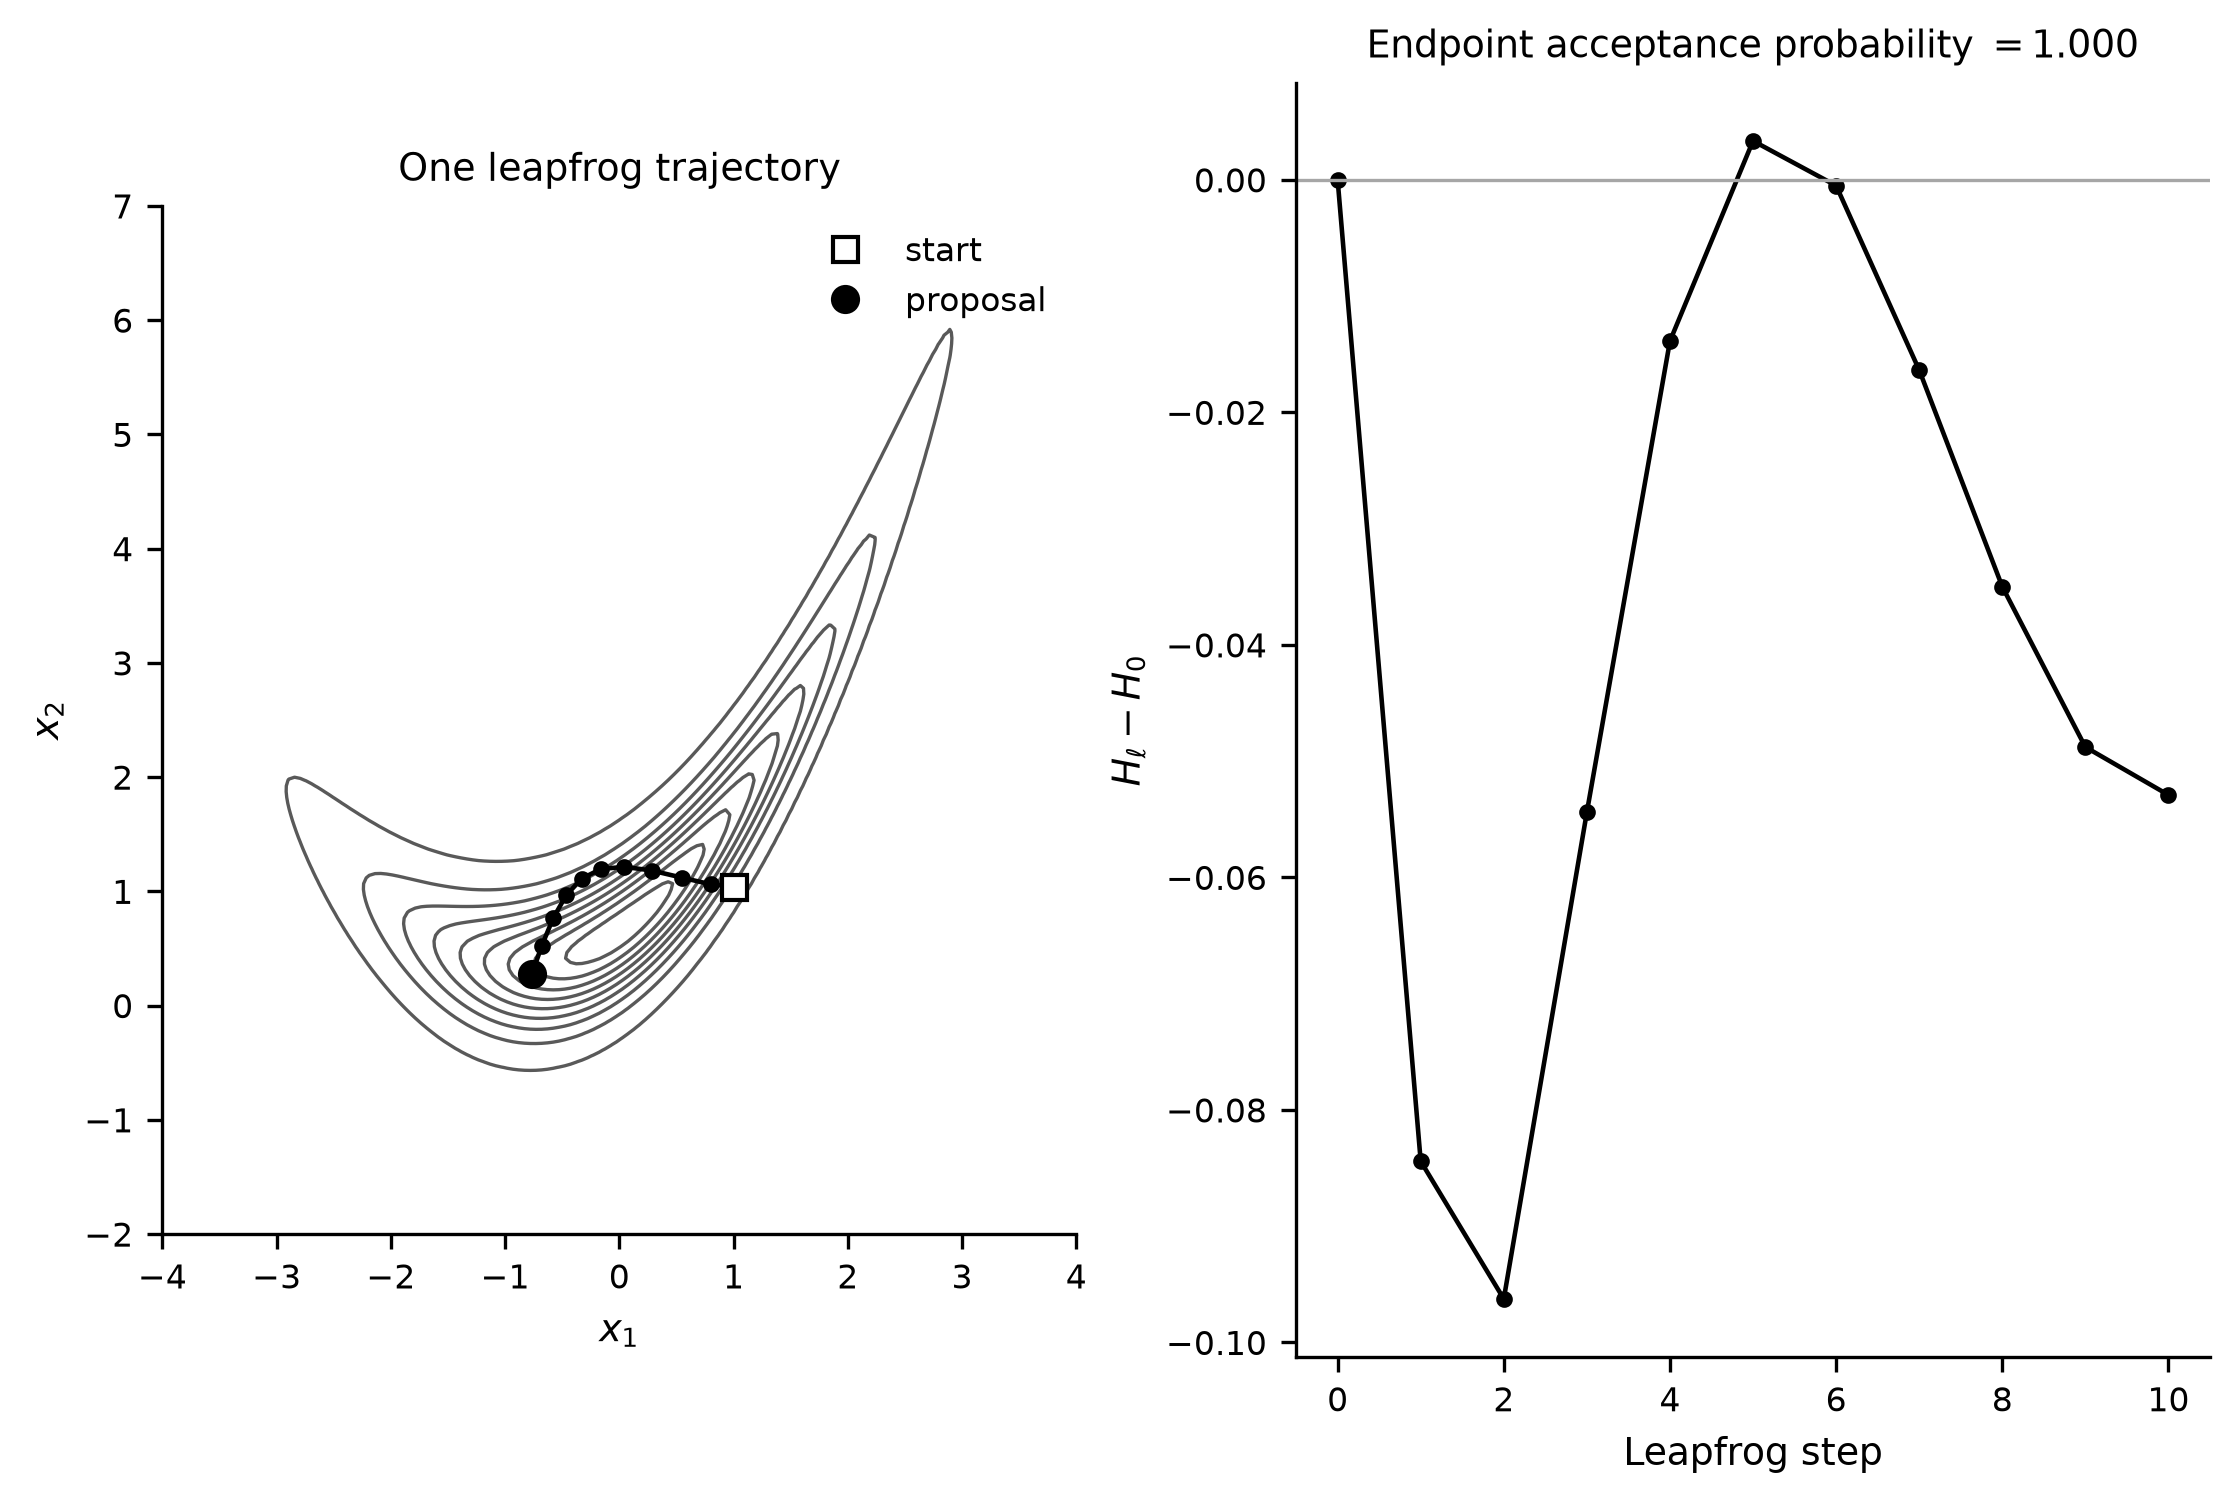

In [4]:
metric = metrics.default_metric(inverse_mass_matrix)
leapfrog = integrators.velocity_verlet(banana_logdensity, metric.kinetic_energy)

trajectory_initial_position = jnp.array([1.0, 1.04])
trajectory_hmc_state = hmc.init(trajectory_initial_position)
trajectory_momentum = metric.sample_momentum(
    trajectory_key,
    trajectory_initial_position,
)
trajectory_initial_state = integrators.IntegratorState(
    trajectory_hmc_state.position,
    trajectory_momentum,
    trajectory_hmc_state.logdensity,
    trajectory_hmc_state.logdensity_grad,
)


def hamiltonian(state):
    return -state.logdensity + metric.kinetic_energy(state.momentum)


def leapfrog_step(state, _):
    next_state = leapfrog(state, step_size)
    return next_state, (next_state.position, hamiltonian(next_state))


trajectory_final_state, (trajectory_positions, trajectory_energies) = lax.scan(
    leapfrog_step,
    trajectory_initial_state,
    None,
    length=num_integration_steps,
)
trajectory_positions = np.vstack(
    [
        np.asarray(trajectory_initial_position),
        np.asarray(trajectory_positions),
    ]
)
trajectory_energies = np.concatenate(
    [
        np.asarray([hamiltonian(trajectory_initial_state)]),
        np.asarray(trajectory_energies),
    ]
)
trajectory_energy_error = trajectory_energies - trajectory_energies[0]
endpoint_acceptance_probability = min(
    1.0,
    float(np.exp(-trajectory_energy_error[-1])),
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=FIGURE_SIZES["full_standard"],
    constrained_layout=True,
)
draw_target_contours(axes[0])
axes[0].plot(
    trajectory_positions[:, 0],
    trajectory_positions[:, 1],
    color="black",
    marker="o",
    markersize=3,
)
axes[0].plot(
    trajectory_positions[0, 0],
    trajectory_positions[0, 1],
    marker="s",
    markerfacecolor="white",
    markeredgecolor="black",
    linestyle="none",
    label="start",
)
axes[0].plot(
    trajectory_positions[-1, 0],
    trajectory_positions[-1, 1],
    marker="o",
    color="black",
    linestyle="none",
    label="proposal",
)
axes[0].legend()
axes[0].set_title("One leapfrog trajectory")

axes[1].plot(
    np.arange(num_integration_steps + 1),
    trajectory_energy_error,
    color="black",
    marker="o",
    markersize=3,
)
axes[1].axhline(0.0, color="0.65", linewidth=0.8)
axes[1].set_xlabel("Leapfrog step")
axes[1].set_ylabel(r"$H_\ell-H_0$")
axes[1].set_title(
    rf"Endpoint acceptance probability $={endpoint_acceptance_probability:.3f}$"
)
finish_axes(axes);


## Warmup and inference draws

We start four chains from the same dispersed positions used in the random-walk experiment. The first $1{,}000$ iterations form a pre-specified warmup phase used only to reduce sensitivity to initialization. The HMC parameters remain fixed. A separate inference phase then retains every one of the $10{,}000$ draws from each chain.

The warmup length is not chosen by looking for a retrospective diagnostic threshold. All diagnostics and estimates below use only the post-warmup inference array.


In [5]:
initial_positions = jnp.array(
    [
        [-4.0, 1.0],
        [-1.0, -1.0],
        [1.0, 4.0],
        [4.0, 6.0],
    ]
)

num_chains = initial_positions.shape[0]
num_warmup = 1_000
num_draws = 10_000

warmup_keys = jrandom.split(warmup_key, num_chains)
initial_states = vmap(hmc.init)(initial_positions)
(
    warmup_final_states,
    warmup_samples,
    warmup_acceptance_probability,
    warmup_is_divergent,
    warmup_energy_error,
    warmup_initial_energy,
) = vmap(run_chain, in_axes=(0, 0, None))(
    warmup_keys,
    initial_states,
    num_warmup,
)

inference_keys = jrandom.split(inference_key, num_chains)
(
    _,
    samples,
    inference_acceptance_probability,
    inference_is_divergent,
    inference_energy_error,
    inference_initial_energy,
) = vmap(run_chain, in_axes=(0, 0, None))(
    inference_keys,
    warmup_final_states,
    num_draws,
)

samples.shape


(4, 10000, 2)

The trace display includes the entire warmup and the first $1{,}500$ inference draws. The vertical line marks their boundary; the numerical summaries use all $40{,}000$ post-warmup states.


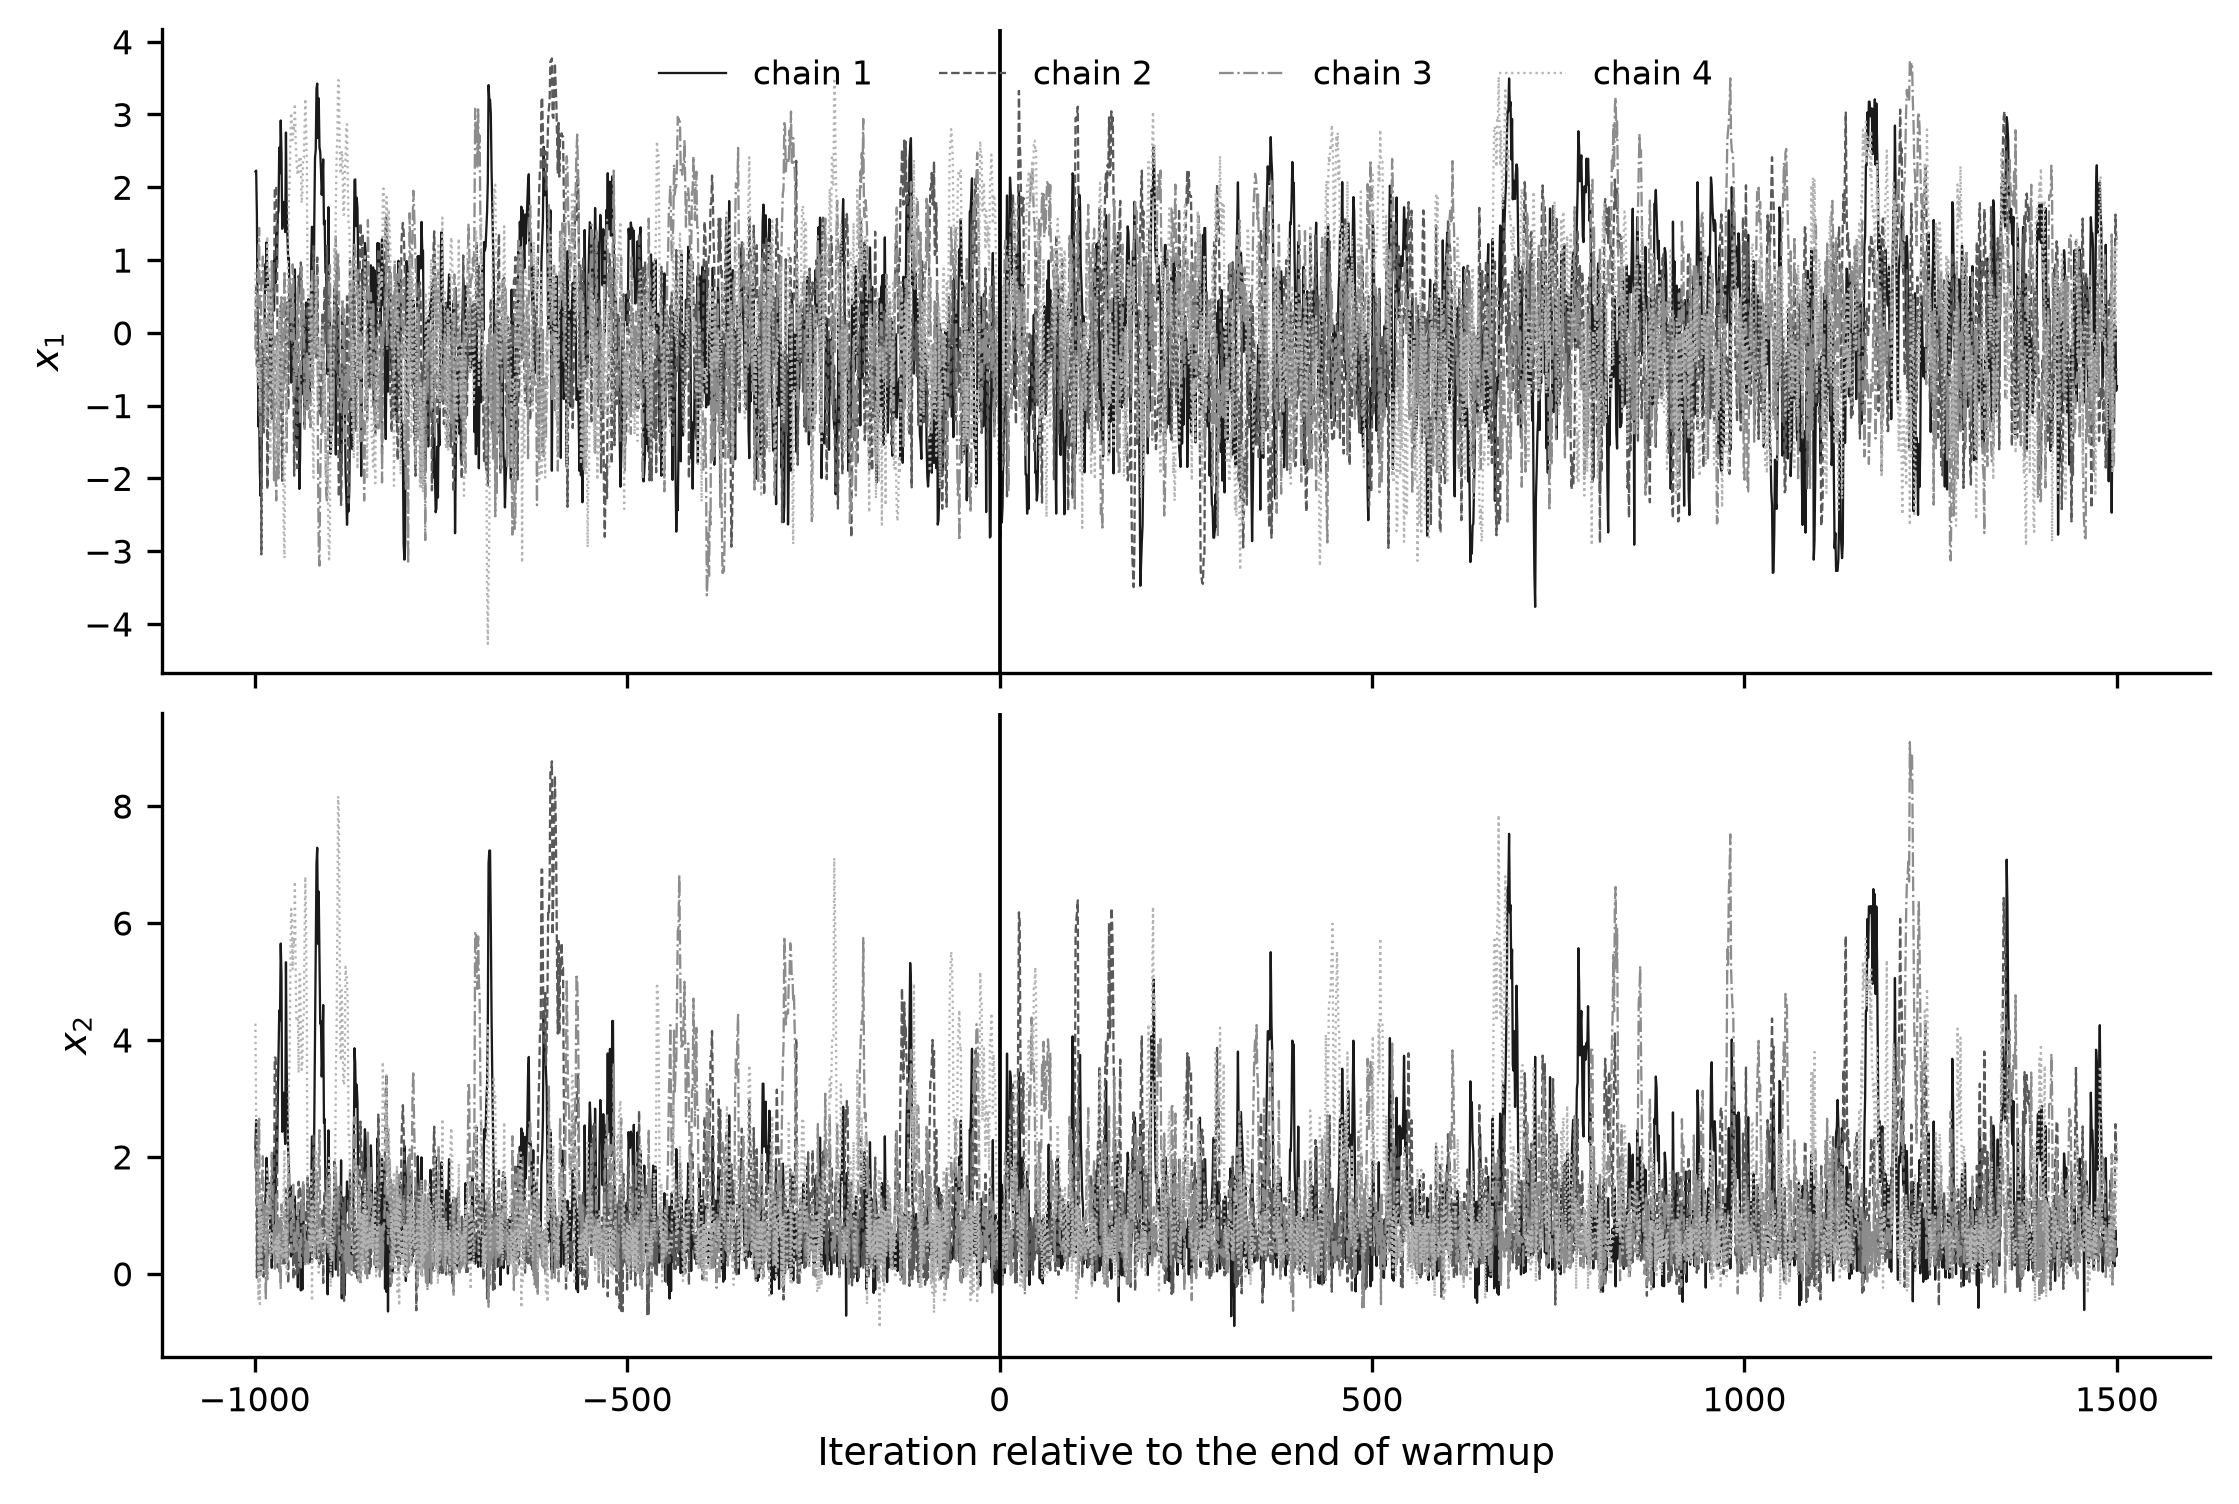

In [6]:
trace_draws = 1_500
trace_values = np.concatenate(
    [np.asarray(warmup_samples), np.asarray(samples[:, :trace_draws])],
    axis=1,
)
trace_iteration = np.arange(-num_warmup + 1, trace_draws + 1)

fig, axes = plt.subplots(
    2,
    1,
    sharex=True,
    figsize=FIGURE_SIZES["full_standard"],
    constrained_layout=True,
)
for chain in range(num_chains):
    color, linestyle = CHAIN_STYLES[chain]
    for coordinate, ax in enumerate(axes):
        ax.plot(
            trace_iteration,
            trace_values[chain, :, coordinate],
            color=color,
            linestyle=linestyle,
            linewidth=0.55,
            rasterized=True,
            label=f"chain {chain + 1}" if coordinate == 0 else None,
        )

for coordinate, ax in enumerate(axes):
    ax.axvline(0, color="black", linewidth=0.9)
    ax.set_ylabel(fr"$x_{coordinate + 1}$")
axes[0].legend(ncol=4, loc="upper center")
axes[-1].set_xlabel("Iteration relative to the end of warmup")
finish_axes(axes);


## Multiple-chain and HMC diagnostics

We compute rank-normalized split and folded $\widehat R$, together with bulk and tail effective sample sizes, on the post-warmup draws {cite:p}`vehtari2021rank`. We also inspect mean acceptance probabilities, divergent-transition flags, and Hamiltonian errors reconstructed from BlackJAX transition information. For one transition, define

$$
\Delta H=H(x_L,-r_L)-H(x_0,r_0).
$$

The acceptance probability is $\min\{1,\exp(-\Delta H)\}$. BlackJAX returns the proposal-endpoint energy and the initial momentum, from which the code reconstructs $\Delta H$. In the pinned implementation, a divergence is flagged when $\Delta H>1{,}000$; an undefined energy difference is also treated as divergent. This one-sided screen is distinct from the separately reported $\max|\Delta H|$.

We also compute E-BFMI. For one chain of $N$ post-warmup transitions, let $E_n=H(x_{n-1},r_n)$ be the initial Hamiltonian after the momentum refresh for transition $n$, and let $\bar E=N^{-1}\sum_{n=1}^N E_n$. Then

$$
\widehat{\operatorname{E\!-\!BFMI}}
=
\frac{(N-1)^{-1}\sum_{n=2}^{N}(E_n-E_{n-1})^2}
{N^{-1}\sum_{n=1}^{N}(E_n-\bar E)^2}.
$$

Small values warn that momentum refreshes do not traverse the marginal energy distribution effectively. The finite-sample ratio is not constrained to $[0,1]$, so a value slightly above one is valid. E-BFMI concerns energy exploration, whereas $\Delta H$ measures numerical integration error. Neither the absence of divergences nor an acceptable E-BFMI is a convergence certificate {cite:p}`betancourt2017conceptual`.


In [7]:
rhat = np.asarray(blackjax.rhat(samples))
bulk_ess = np.asarray(blackjax.ess_bulk(samples))
tail_ess = np.asarray(blackjax.ess_tail(samples))

diagnostic_rows = [
    ["Rank-normalized split/folded R-hat", f"{rhat[0]:.4f}", f"{rhat[1]:.4f}"],
    ["Bulk ESS", f"{bulk_ess[0]:.0f}", f"{bulk_ess[1]:.0f}"],
    ["Tail ESS", f"{tail_ess[0]:.0f}", f"{tail_ess[1]:.0f}"],
]
diagnostic_latex = rf'''
\begin{{tabular}}{{lrr}}
\hline
Quantity & $x_1$ & $x_2$ \\
\hline
Rank-normalized split/folded $\widehat R$ & {rhat[0]:.4f} & {rhat[1]:.4f} \\
Bulk ESS & {bulk_ess[0]:.0f} & {bulk_ess[1]:.0f} \\
Tail ESS & {tail_ess[0]:.0f} & {tail_ess[1]:.0f} \\
\hline
\end{{tabular}}
'''
math_class = 'class="math notranslate nohighlight"'
diagnostic_html_headers = [
    "Quantity",
    f"<span {math_class}>\\(x_1\\)</span>",
    f"<span {math_class}>\\(x_2\\)</span>",
]
diagnostic_html_rows = [
    [
        f"Rank-normalized split/folded <span {math_class}>\\(\\widehat R\\)</span>",
        diagnostic_rows[0][1],
        diagnostic_rows[0][2],
    ],
    diagnostic_rows[1],
    diagnostic_rows[2],
]
display_book_table(
    ["Quantity", "x1", "x2"],
    diagnostic_rows,
    diagnostic_latex,
    html_headers=diagnostic_html_headers,
    html_rows=diagnostic_html_rows,
)

mean_acceptance_probability = np.asarray(inference_acceptance_probability).mean(axis=1)
divergence_count = np.asarray(inference_is_divergent).sum(axis=1)
maximum_energy_error = np.max(np.abs(np.asarray(inference_energy_error)), axis=1)
energy_values = np.asarray(inference_initial_energy)
e_bfmi = np.mean(np.diff(energy_values, axis=1) ** 2, axis=1) / np.var(
    energy_values,
    axis=1,
)

hmc_rows = []
for chain in range(num_chains):
    hmc_rows.append(
        [
            str(chain + 1),
            f"{mean_acceptance_probability[chain]:.3f}",
            str(int(divergence_count[chain])),
            f"{maximum_energy_error[chain]:.3f}",
            f"{e_bfmi[chain]:.3f}",
        ]
    )

hmc_latex_rows = [" & ".join(row) + r" \\" for row in hmc_rows]
hmc_latex = r'''
\begin{tabular}{lrrrr}
\hline
Chain & Mean accept. prob. & Divergences & $\max|\Delta H|$ & E-BFMI \\
\hline
''' + "\n".join(hmc_latex_rows) + r'''
\hline
\end{tabular}
'''
display_book_table(
    [
        "Chain",
        "Mean accept. prob.",
        "Divergences",
        "max |delta H|",
        "E-BFMI",
    ],
    hmc_rows,
    hmc_latex,
    html_headers=[
        "Chain",
        "Mean accept. prob.",
        "Divergences",
        f"<span {math_class}>\\(\\max|\\Delta H|\\)</span>",
        "E-BFMI",
    ],
)


Quantity,\(x_1\),\(x_2\)
Rank-normalized split/folded \(\widehat R\),1.0002,1.0004
Bulk ESS,4626,6435
Tail ESS,4832,4803


Chain,Mean accept. prob.,Divergences,\(\max|\Delta H|\),E-BFMI
1,0.987,0,0.982,0.967
2,0.987,0,1.012,0.990
3,0.987,0,1.217,0.999
4,0.987,0,0.729,1.008


Pooled-rank histograms provide a complementary graphical check. Chains exploring the same distribution should contribute comparably throughout the pooled ranks; exact uniformity is neither expected nor required.


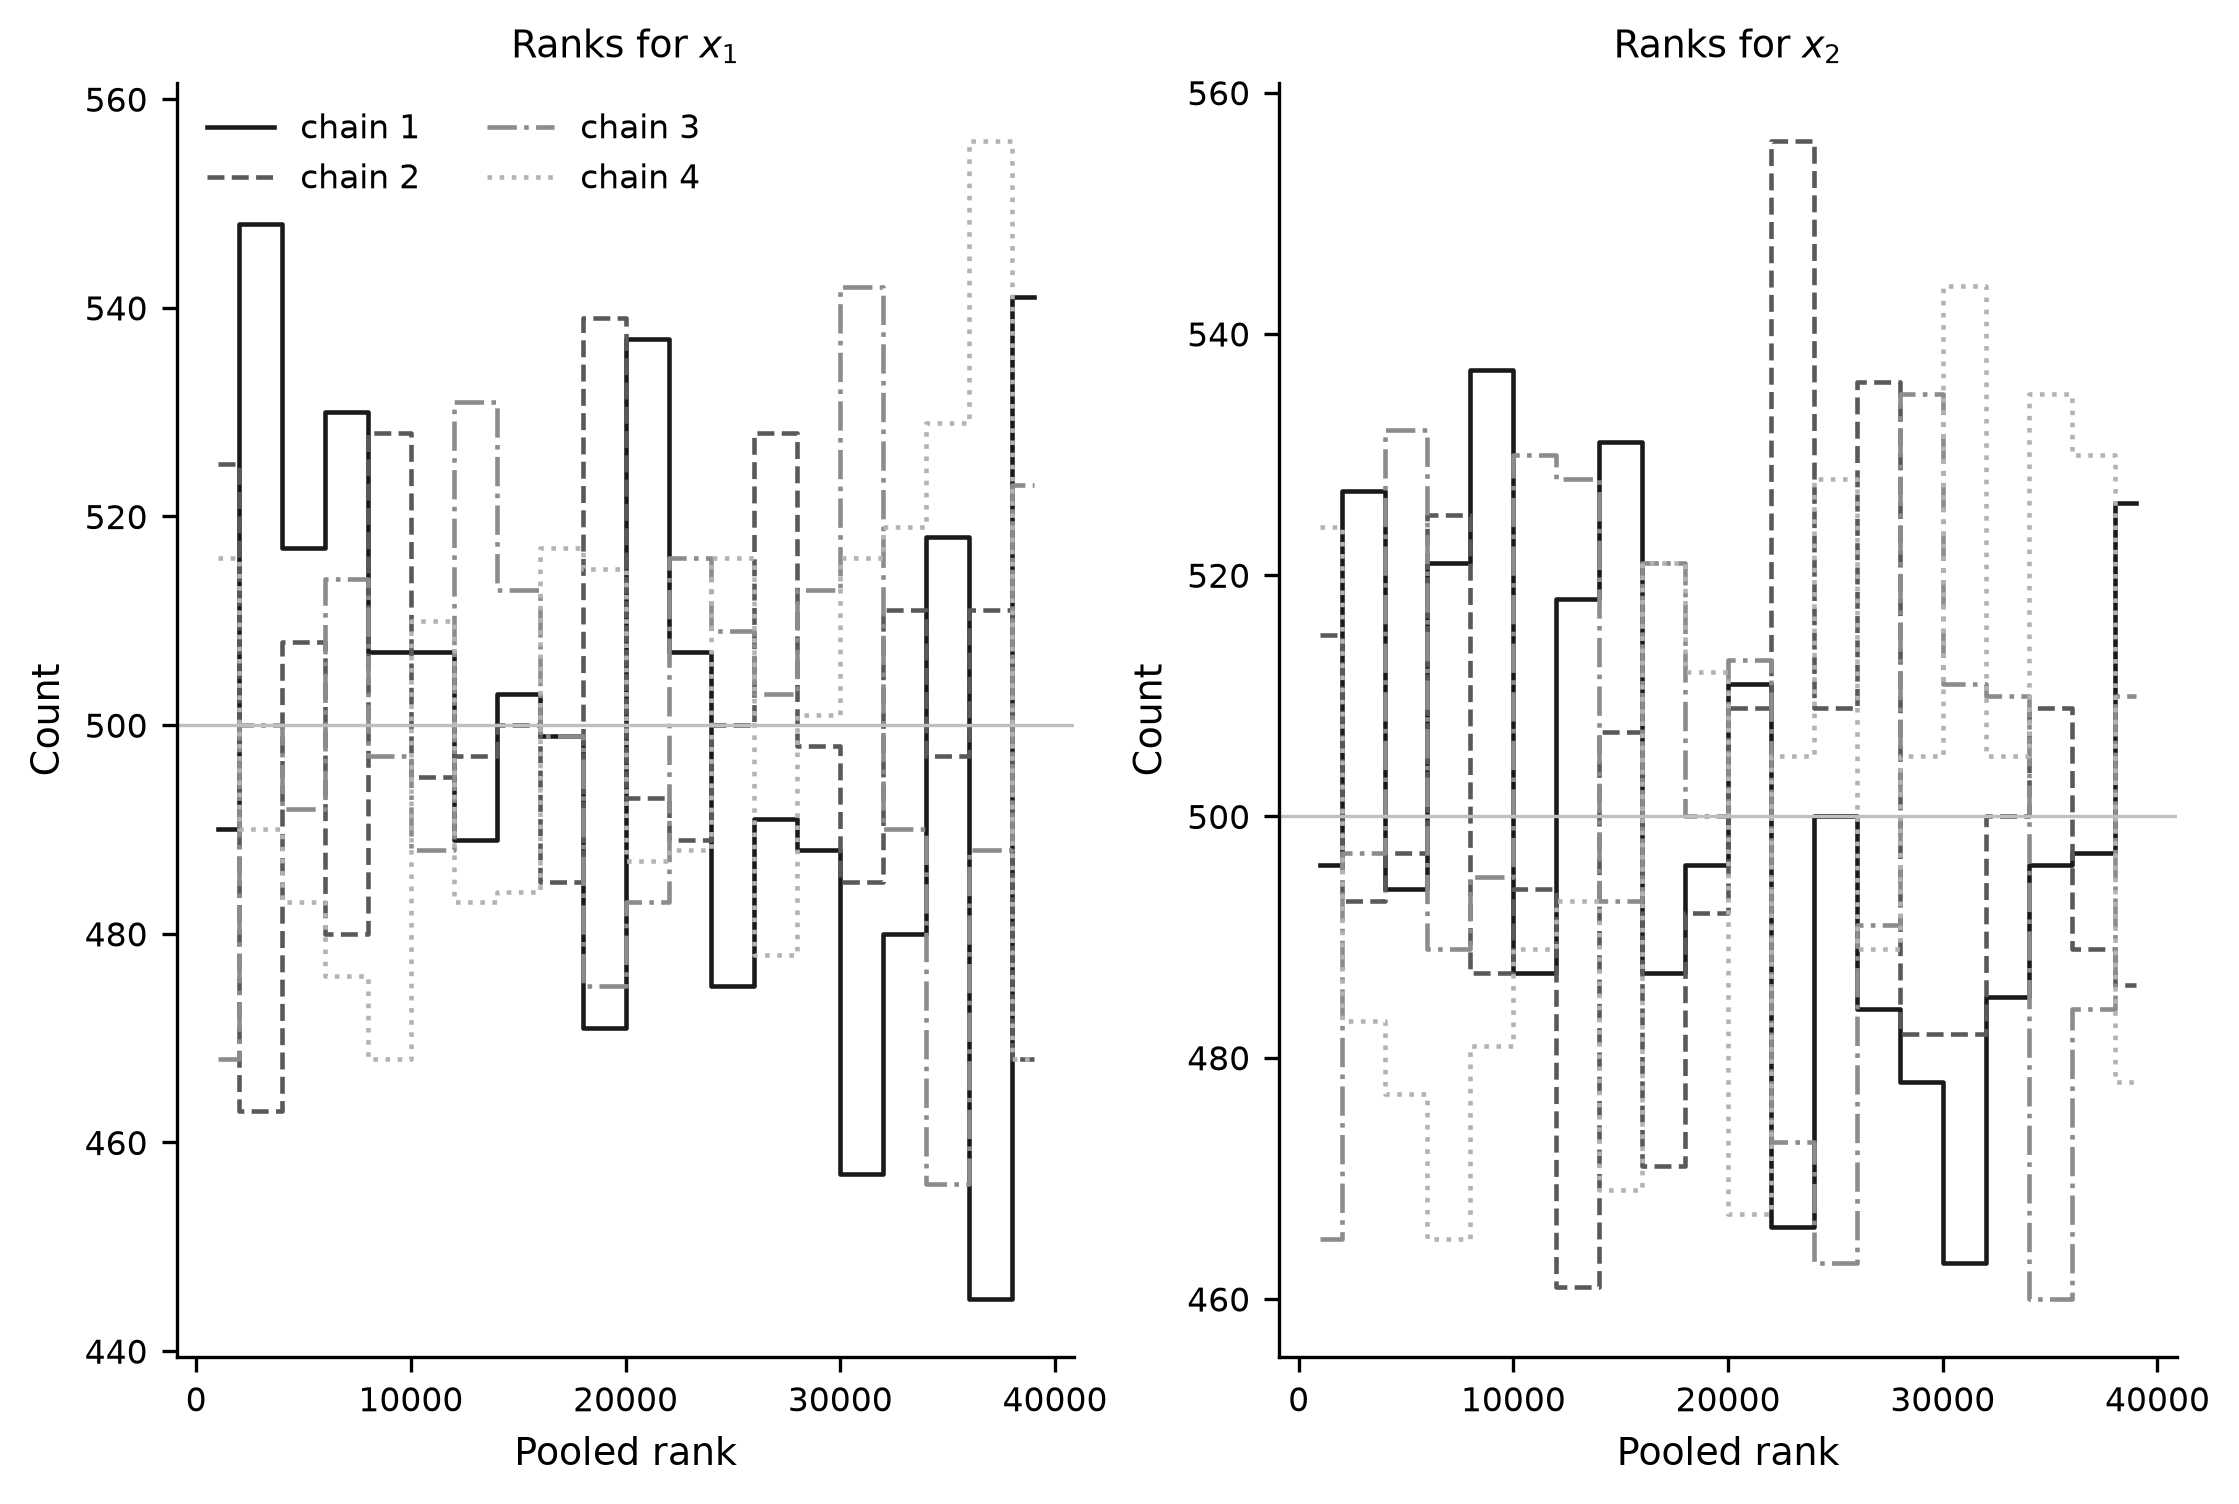

In [8]:
num_rank_bins = 20
fig, axes = plt.subplots(
    1,
    2,
    figsize=FIGURE_SIZES["full_standard"],
    constrained_layout=True,
)

for coordinate, ax in enumerate(axes):
    pooled = np.asarray(samples[:, :, coordinate])
    ranks = rankdata(pooled.ravel(), method="average").reshape(pooled.shape)
    bin_edges = np.linspace(0.5, ranks.size + 0.5, num_rank_bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    for chain in range(num_chains):
        color, linestyle = CHAIN_STYLES[chain]
        counts, _ = np.histogram(ranks[chain], bins=bin_edges)
        ax.step(
            bin_centers,
            counts,
            where="mid",
            color=color,
            linestyle=linestyle,
            label=f"chain {chain + 1}",
        )
    ax.axhline(num_draws / num_rank_bins, color="0.75", linewidth=0.8)
    ax.set_title(fr"Ranks for $x_{coordinate + 1}$")
    ax.set_xlabel("Pooled rank")
    ax.set_ylabel("Count")

axes[0].legend(ncol=2)
finish_axes(axes);


## Monte Carlo precision and an exact check

The transformation gives the exact moments

$$
\begin{aligned}
\mathbb{E}[X_1]&=0,
&\mathbb{E}[X_2]&=b(1+a^2),\\
\mathbb{E}[X_1^2]&=a^2,
&\mathbb{E}[X_1X_2]&=\rho,\\
\operatorname{Var}(X_2)&=a^{-2}+2b^2.
\end{aligned}
$$

Consequently,

$$
\mathbb{E}[X_2^2]
=
a^{-2}+2b^2+b^2(1+a^2)^2.
$$

For each scalar estimand $g(X)$, we report

$$
\operatorname{MCSE}(\bar g)
\approx
\sqrt{\frac{\widehat{\operatorname{Var}}(g(X))}{N_{\mathrm{eff},g}}}.
$$

Here $\bar g$ is the average over all retained chains and draws, $\widehat{\operatorname{Var}}(g(X))$ is their pooled sample variance, and $N_{\mathrm{eff},g}$ is the estimand-specific effective sample size for that average.


In [9]:
moment_draws = jnp.stack(
    [
        samples[..., 0],
        samples[..., 1],
        samples[..., 0] ** 2,
        samples[..., 0] * samples[..., 1],
        samples[..., 1] ** 2,
    ],
    axis=-1,
)

exact_moments = np.array(
    [
        0.0,
        b * (1.0 + a**2),
        a**2,
        rho,
        a ** (-2) + 2.0 * b**2 + b**2 * (1.0 + a**2) ** 2,
    ]
)
moment_names = [
    "E[X1]",
    "E[X2]",
    "E[X1^2]",
    "E[X1 X2]",
    "E[X2^2]",
]
moment_names_latex = [
    r"$\mathbb{E}[X_1]$",
    r"$\mathbb{E}[X_2]$",
    r"$\mathbb{E}[X_1^2]$",
    r"$\mathbb{E}[X_1X_2]$",
    r"$\mathbb{E}[X_2^2]$",
]
moment_names_html = [
    f"<span {math_class}>\\(\\mathbb{{E}}[X_1]\\)</span>",
    f"<span {math_class}>\\(\\mathbb{{E}}[X_2]\\)</span>",
    f"<span {math_class}>\\(\\mathbb{{E}}[X_1^2]\\)</span>",
    f"<span {math_class}>\\(\\mathbb{{E}}[X_1X_2]\\)</span>",
    f"<span {math_class}>\\(\\mathbb{{E}}[X_2^2]\\)</span>",
]

moment_estimates = np.asarray(moment_draws.mean(axis=(0, 1)))
moment_ess = np.asarray(blackjax.ess(moment_draws))
moment_rhat = np.asarray(blackjax.rhat(moment_draws))
moment_variances = np.asarray(moment_draws).reshape(-1, len(moment_names)).var(
    axis=0,
    ddof=1,
)
moment_mcse = np.sqrt(moment_variances / moment_ess)

moment_rows = []
for name, exact, estimate, mcse, value_rhat, value_ess in zip(
    moment_names,
    exact_moments,
    moment_estimates,
    moment_mcse,
    moment_rhat,
    moment_ess,
):
    moment_rows.append(
        [
            name,
            f"{exact:.4f}",
            f"{estimate:.4f}",
            f"{mcse:.4f}",
            f"{value_rhat:.4f}",
            f"{value_ess:.0f}",
        ]
    )

moment_latex_rows = []
for name, row in zip(moment_names_latex, moment_rows):
    moment_latex_rows.append(name + " & " + " & ".join(row[1:]) + r" \\")
moment_latex = r'''
\begin{tabular}{lrrrrr}
\hline
Estimand & Exact & Estimate & MCSE & $\widehat R$ & ESS for $\bar g$ \\
\hline
''' + "\n".join(moment_latex_rows) + r'''
\hline
\end{tabular}
'''
moment_html_rows = [
    [html_name] + row[1:]
    for html_name, row in zip(moment_names_html, moment_rows)
]
display_book_table(
    ["Estimand", "Exact", "Estimate", "MCSE", "R-hat", "ESS for mean"],
    moment_rows,
    moment_latex,
    html_headers=[
        "Estimand",
        "Exact",
        "Estimate",
        "MCSE",
        f"<span {math_class}>\\(\\widehat R\\)</span>",
        f"ESS for <span {math_class}>\\(\\bar g\\)</span>",
    ],
    html_rows=moment_html_rows,
)


Estimand,Exact,Estimate,MCSE,\(\widehat R\),ESS for \(\bar g\)
\(\mathbb{E}[X_1]\),0.0000,-0.0037,0.0172,1.0002,4594
\(\mathbb{E}[X_2]\),1.1612,1.1760,0.0181,1.0004,4056
\(\mathbb{E}[X_1^2]\),1.3225,1.3585,0.0244,1.0005,6183
\(\mathbb{E}[X_1X_2]\),0.9000,0.9418,0.0567,1.0004,3405
\(\mathbb{E}[X_2^2]\),2.6046,2.7168,0.1065,1.0004,3373


Every inference state remains in these calculations. The positive serial dependence in this run lowers ESS, but it does not define a thinning interval. Routine thinning would discard information unless storage or downstream processing is the binding constraint {cite:p}`link2012thinning`.

For a readable final figure, the next cell displays every tenth state. This is display subsampling, not analytic thinning: all numerical summaries and moment estimates use the complete inference array.


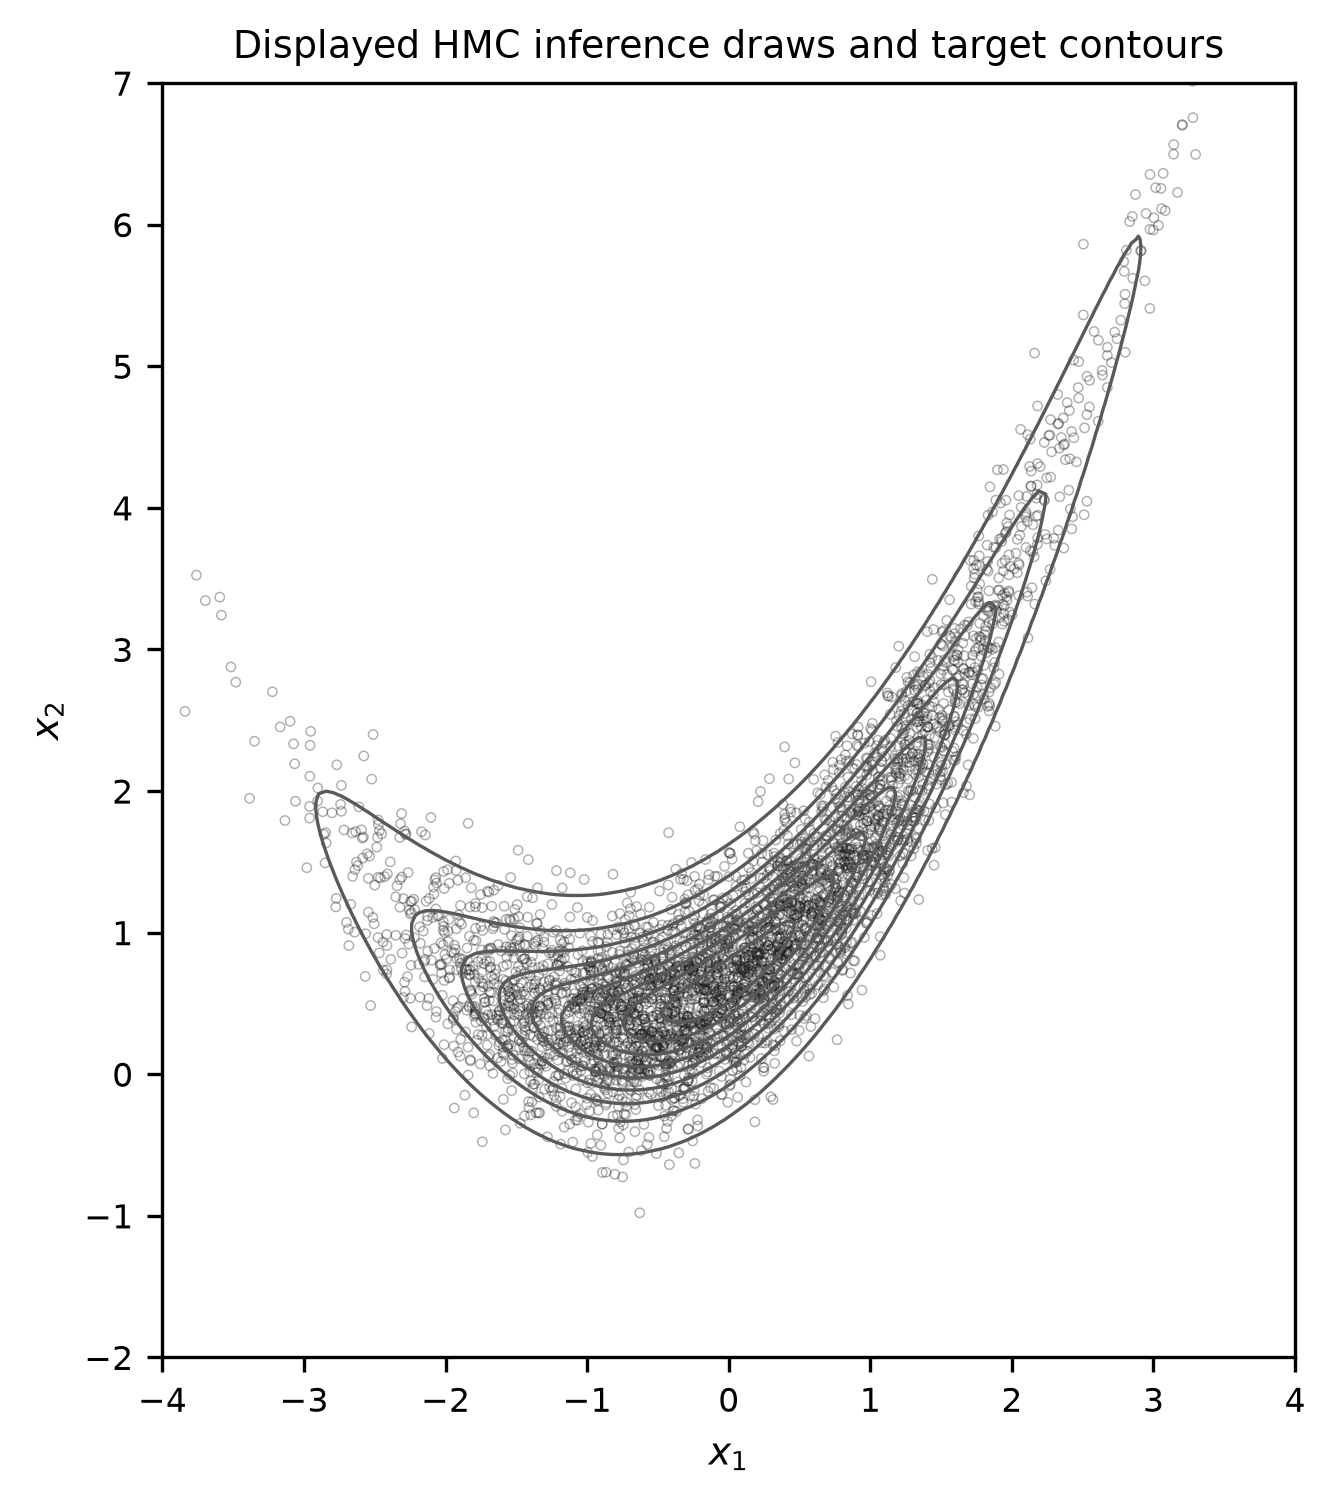

In [10]:
display_stride = 10
display_samples = np.asarray(samples[:, ::display_stride]).reshape(-1, 2)

fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"], constrained_layout=True)
draw_target_contours(ax)
ax.scatter(
    display_samples[:, 0],
    display_samples[:, 1],
    s=5,
    facecolors="none",
    edgecolors="0.10",
    linewidths=0.35,
    alpha=0.35,
    rasterized=True,
)
ax.set_title("Displayed HMC inference draws and target contours");


## Diagnostic interpretation

For this stored run, the coordinate and moment $\widehat R$ values satisfy the $1.01$ warning screen, the rank plots show no clear chain separation, no post-warmup transition is flagged as divergent, and the per-chain E-BFMI values near one reveal no evident energy-exploration warning. The exact moments agree with the estimates at the scale indicated by their MCSEs. The high acceptance probabilities are consistent with a conservative step size; they do not establish convergence. No finite collection of diagnostics certifies convergence.

This HMC run obtains larger coordinate ESS from fewer retained chain states than the preceding random-walk run. That is a chain-state comparison, not a cost-normalized benchmark: each HMC transition here uses ten gradient-based integration steps. A fair comparison would report MCSE per unit wall time and list log-density and gradient evaluations separately.

Fixed-path HMC still requires choices of $\epsilon$, $L$, and $M$. The next notebook introduces the No-U-Turn Sampler, which replaces the manually chosen path length with a trajectory-building rule and uses warmup to adapt the step size and inverse mass matrix.

## Exercises

1. In a separate pilot, vary $\epsilon$ while holding $L$ fixed. Compare acceptance probability, Hamiltonian error, divergences, and ESS. Freeze the selected value before generating fresh inference draws.
2. Compare several $(\epsilon,L)$ pairs with approximately the same nominal trajectory length $L\epsilon$. Explain how discretization error and path length play different roles.
3. Replace $M^{-1}=I_2$ by a diagonal inverse mass matrix chosen from a pilot estimate of scale. Assess its effect using the same post-warmup diagnostics.
4. Compare HMC with the preceding random-walk experiment using MCSE per unit wall time. Report log-density and gradient evaluations separately, and explain why ESS per retained state alone is not a computational-efficiency measure.
